# Phase 1 — Dataset Setup & Exploratory Data Analysis

**Project:** Beyond Binary Detection: Explainable AI Deepfake Localization via Frequency-Aware Segmentation  
**Dataset:** CIFAKE — Real and AI-Generated Synthetic Images  
**Objective:** Verify dataset integrity, understand class distribution, inspect image properties, and detect data quality issues before any model training begins.

## Import Libraries

In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Create Project Output Directories

All result artifacts are stored under `/kaggle/working/results/` with phase-specific subdirectories.

In [2]:
dirs = [
    "/kaggle/working/models",
    "/kaggle/working/checkpoints",
    "/kaggle/working/results/eda",
    "/kaggle/working/results/baseline_spatial",
    "/kaggle/working/results/frequency_analysis",
    "/kaggle/working/results/frequency_cnn",
    "/kaggle/working/results/comparison",
    "/kaggle/working/results/dual_stream",
    "/kaggle/working/results/gradcam",
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Output directories created.")

Output directories created.


## Define Dataset Paths

Paths are defined centrally here and reused throughout the notebook.

In [3]:
BASE_PATH  = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH  = os.path.join(BASE_PATH, "test")

REAL_TRAIN = os.path.join(TRAIN_PATH, "REAL")
FAKE_TRAIN = os.path.join(TRAIN_PATH, "FAKE")
REAL_TEST  = os.path.join(TEST_PATH,  "REAL")
FAKE_TEST  = os.path.join(TEST_PATH,  "FAKE")

for label, path in [("REAL_TRAIN", REAL_TRAIN), ("FAKE_TRAIN", FAKE_TRAIN),
                    ("REAL_TEST",  REAL_TEST),  ("FAKE_TEST",  FAKE_TEST)]:
    status = "OK" if os.path.exists(path) else "NOT FOUND"
    print(f"{label:<12} : {status}  ({path})")

REAL_TRAIN   : OK  (/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL)
FAKE_TRAIN   : OK  (/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE)
REAL_TEST    : OK  (/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/REAL)
FAKE_TEST    : OK  (/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test/FAKE)


## Count Images Per Class

Verifies class balance across training and test splits. An imbalanced dataset would bias model predictions and requires handling before training.

In [4]:
train_real = len(os.listdir(REAL_TRAIN))
train_fake = len(os.listdir(FAKE_TRAIN))
test_real  = len(os.listdir(REAL_TEST))
test_fake  = len(os.listdir(FAKE_TEST))

total_train = train_real + train_fake
total_test  = test_real  + test_fake

print(f"Train — REAL: {train_real:>6,}  |  FAKE: {train_fake:>6,}  |  Total: {total_train:>6,}")
print(f"Test  — REAL: {test_real:>6,}  |  FAKE: {test_fake:>6,}  |  Total: {total_test:>6,}")
print(f"Train balance — REAL: {train_real/total_train*100:.1f}%  FAKE: {train_fake/total_train*100:.1f}%")

Train — REAL: 50,000  |  FAKE: 50,000  |  Total: 100,000
Test  — REAL: 10,000  |  FAKE: 10,000  |  Total: 20,000
Train balance — REAL: 50.0%  FAKE: 50.0%


## Inspect Native Image Dimensions

CIFAKE images are natively 32×32 pixels. This is critical: low resolution limits spatial feature quality and directly motivates the frequency-domain approach.

In [5]:
for label, folder in [("REAL", REAL_TRAIN), ("FAKE", FAKE_TRAIN)]:
    print(f"--- {label} (first 3 samples) ---")
    for name in os.listdir(folder)[:3]:
        img = cv2.imread(os.path.join(folder, name))
        print(f"  {name}: {img.shape}")
    print()

--- REAL (first 3 samples) ---
  4093 (7).jpg: (32, 32, 3)
  3825 (3).jpg: (32, 32, 3)
  4131 (5).jpg: (32, 32, 3)

--- FAKE (first 3 samples) ---
  5387 (6).jpg: (32, 32, 3)
  4093 (7).jpg: (32, 32, 3)
  5357 (8).jpg: (32, 32, 3)



## Visualize Sample Images — REAL vs FAKE

Side-by-side visual comparison of randomly selected training images. At 32×32 resolution, perceptual differences between classes are difficult to discern by eye.

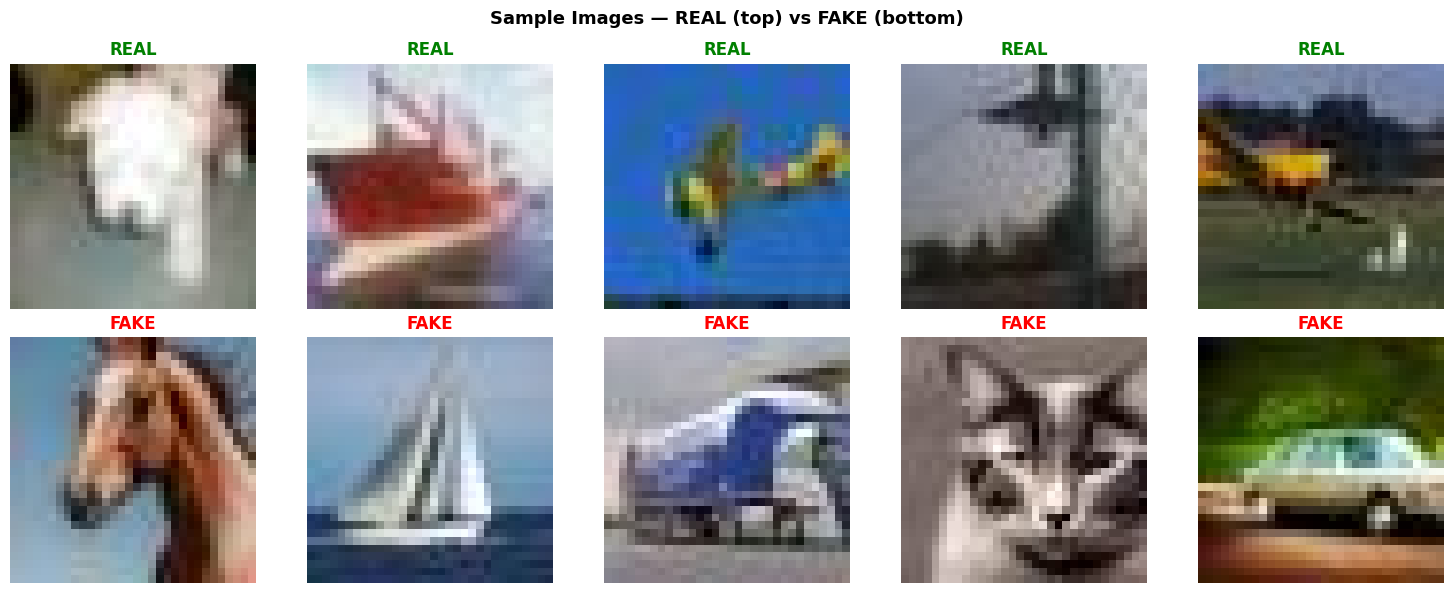

In [6]:
real_files = os.listdir(REAL_TRAIN)
fake_files = os.listdir(FAKE_TRAIN)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images — REAL (top) vs FAKE (bottom)", fontsize=13, fontweight="bold")

for col in range(5):
    r = Image.open(os.path.join(REAL_TRAIN, random.choice(real_files)))
    f = Image.open(os.path.join(FAKE_TRAIN, random.choice(fake_files)))

    axes[0, col].imshow(r)
    axes[0, col].set_title("REAL", color="green", fontweight="bold")
    axes[0, col].axis("off")

    axes[1, col].imshow(f)
    axes[1, col].set_title("FAKE", color="red", fontweight="bold")
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/results/eda/sample_real_vs_fake.png", dpi=150, bbox_inches="tight")
plt.show()

## Class Distribution Bar Chart

Visual confirmation of dataset balance across train and test splits.

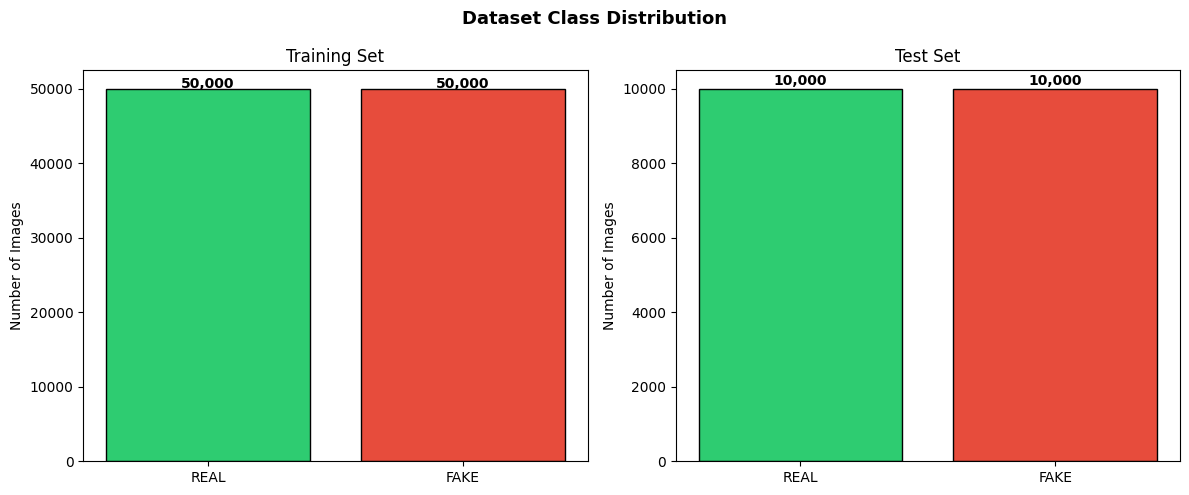

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Dataset Class Distribution", fontsize=13, fontweight="bold")

colors = ["#2ecc71", "#e74c3c"]

for ax, counts, title in [
    (axes[0], [train_real, train_fake], "Training Set"),
    (axes[1], [test_real,  test_fake],  "Test Set"),
]:
    bars = ax.bar(["REAL", "FAKE"], counts, color=colors, edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel("Number of Images")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 100,
                f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/results/eda/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Detect Corrupted Images

Corrupted images can silently break training. The first 500 images per class are scanned using PIL's verify method.

In [8]:
corrupted = []

for label, folder in [("REAL", REAL_TRAIN), ("FAKE", FAKE_TRAIN)]:
    for name in os.listdir(folder)[:500]:
        path = os.path.join(folder, name)
        try:
            img = Image.open(path)
            img.verify()
        except Exception:
            corrupted.append(path)

print(f"Corrupted images found : {len(corrupted)}")
for c in corrupted:
    print(f"  {c}")

Corrupted images found : 0


## Save EDA Summary Report

In [9]:
report = f"""PHASE 1 — EDA SUMMARY
{'='*40}
Dataset       : CIFAKE
Native size   : 32 x 32 px
Training size : 128 x 128 px (resized)

Train — REAL  : {train_real:,}
Train — FAKE  : {train_fake:,}
Train — Total : {total_train:,}

Test  — REAL  : {test_real:,}
Test  — FAKE  : {test_fake:,}
Test  — Total : {total_test:,}

Balance       : {train_real/total_train*100:.1f}% REAL / {train_fake/total_train*100:.1f}% FAKE
Corrupted     : {len(corrupted)}

Key Finding:
Native 32x32 resolution limits spatial feature richness.
This directly motivates frequency-domain (DCT) analysis.
"""

with open("/kaggle/working/results/eda/eda_summary.txt", "w") as f:
    f.write(report)

print(report)

PHASE 1 — EDA SUMMARY
Dataset       : CIFAKE
Native size   : 32 x 32 px
Training size : 128 x 128 px (resized)

Train — REAL  : 50,000
Train — FAKE  : 50,000
Train — Total : 100,000

Test  — REAL  : 10,000
Test  — FAKE  : 10,000
Test  — Total : 20,000

Balance       : 50.0% REAL / 50.0% FAKE
Corrupted     : 0

Key Finding:
Native 32x32 resolution limits spatial feature richness.
This directly motivates frequency-domain (DCT) analysis.



---
## Phase 1 Complete

| Finding | Value |
|---|---|
| Total training images | 100,000 |
| Class balance | Perfectly balanced (50/50) |
| Native resolution | 32 × 32 px |
| Corrupted images | 0 |

**Next → Phase 2: Baseline Spatial CNN**

## Download Phase 1 Outputs

Run this cell after all steps above are complete to package and download all Phase 1 results.

In [10]:
import shutil, os

OUTPUT_FILES = [
    "/kaggle/working/results/eda/sample_real_vs_fake.png",
    "/kaggle/working/results/eda/class_distribution.png",
    "/kaggle/working/results/eda/eda_summary.txt",
]

shutil.make_archive("/kaggle/working/phase_01_outputs", "zip", "/kaggle/working/results/eda")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / 1024, 1) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} KB")

print()
print("Download: /kaggle/working/phase_01_outputs.zip")

Files packaged:
  OK       sample_real_vs_fake.png                       67.0 KB
  OK       class_distribution.png                        44.3 KB
  OK       eda_summary.txt                               0.5 KB

Download: /kaggle/working/phase_01_outputs.zip
